# Joint photometry and spectroscopy

## What you will do
Fit broadband photometry and an optical spectrum together. You'll see how the joint posterior resolves degeneracies that neither dataset alone can break: stellar metallicity and dust optical depth, which were degenerate in photometry-only fits, separate when absorption-line depths anchor the age and metallicity.

## What you need
An SSP grid, broadband filters (UV through mid-IR), and a medium-resolution optical spectrum (R ≈ 2000) covering age and metallicity-sensitive absorption lines.

## What you will have
A narrower joint posterior with tight constraints on all free parameters, because the two datasets constrain different degeneracies.

---

Broadband photometry alone leaves the SFH shape and the metallicity–dust split prior-dominated. An optical spectrum covers metallicity-sensitive absorption features (Hβ, Mgb, Fe blends) and tightens age and metallicity, but the dust optical depth stays loose. Fitting both together yields a joint posterior narrower than either alone: the line depths break the age–metallicity–dust ridge. The machinery is the same as the quickstart (SEDModel.build with validated HMC), with one `Observation` carrying both channels.

In [1]:
from _setup import FIG_DIR, HMC_VALIDATED, effective_wavelengths_um, quiet

quiet()

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    builders,
    cosmology,
    Data,
    DEFAULT,
    Fixed,
    ForwardModel,
    FREE,
    Observation,
    Photometry,
    plot,
    SEDModel,
    Spectroscopy,
    SpectrumPrecomp,
    Uniform,
    WavePrecomp,
)
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()

C_POST, C_TRUTH, C_DATA, C_SPEC = "#3a76d9", "0.15", "#c3372a", "#d98a3a"

## Stellar library and observation

Twelve UV–MIR bands (GALEX → WISE) plus an SDSS-like optical spectrum (R ≈ 2000,
3800–9200 Å observed). At z = 0.05 this covers the 4000 Å break, Hβ, Mgb triplet,
Fe5270/Fe5335 blends, Hα, and Ca II triplet — the absorption features that carry
metallicity and light-weighted age. Sampling at 260 pixels resolves these indices.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"
ssp = tengri.load_ssp(SSP_NAME, download=True)

Z_GAL = 0.05
FILTERS = [
    "galex_fuv",
    "galex_nuv",
    "sdss_u",
    "sdss_g",
    "sdss_r",
    "sdss_i",
    "sdss_z",
    "2mass_j",
    "2mass_h",
    "2mass_ks",
    "wise_w1",
    "wise_w2",
]
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 260)  # SDSS spectral coverage

phot_obs = Photometry.from_names(FILTERS)
spec_obs = Spectroscopy(wave_obs=WAVE_OBS, resolution=2000)
obs_phot = Observation(photometry=phot_obs)
obs_joint = Observation(photometry=phot_obs, spectroscopy=spec_obs)

## Build the model

One builder, called twice: the same physics and the same free parameters
against two different observations. The spectrum's pixel count drives the fit
cost — each pixel adds a likelihood term and a gradient row.

**Both channels assume Gaussian, uncorrelated errors.** That holds for the
photometry, but real spectral pixels share correlated noise (wavelength
calibration, flat-fielding). This fit uses diagonal errors, so the posterior
width is honest about the data it was given and does not account for that
structure.

In [3]:
def build(obs, approx=None):
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        approx=approx,
        # Free the SFH normalization + the two timescale parameters; fix the
        # skew/truncation shape nuisances (neither photometry nor a continuum
        # spectrum constrains them, and free they mix poorly under HMC).
        sfh=builders.sfh.tsnorm(
            all_params=Fixed(DEFAULT), log_total_mass=FREE, peak_lbt_gyr=FREE, width_gyr=FREE
        ),
        dust_attenuation=builders.dust.two_component(
            all_params=Fixed(DEFAULT),
            law="calzetti",
            tau_bc=Uniform(0.0, 1.0),
            tau_diff=Uniform(0.0, 1.0),
        ),
        dust_emission=builders.dust.emission.modified_blackbody(all_params=Fixed(DEFAULT)),
        neb=builders.neb.none(),
        met={"logzsol": Uniform(-1.5, 0.3)},
        redshift=Fixed(Z_GAL),
    )


# Both fits use lookup tables. Photometry-only gets WavePrecomp (SSP × filter
# LUT). The joint model gets SpectrumPrecomp, which builds both LUT families
# side by side — the SSP × filter table for the photometry channel and the
# SSP × pixel table for the spectrum — so neither channel falls back to the
# slow exact wave-grid integration.
model_phot = build(obs_phot, approx=WavePrecomp())
model_joint = build(obs_joint, approx=SpectrumPrecomp())
print(
    f"Free parameters ({model_joint.spec.n_free}): {', '.join(model_joint.spec.free_params)}",
    flush=True,
)

Free parameters (6): dust_tau_bc, dust_tau_diff, met_logzsol, sfh_tsnorm_log_total_mass, sfh_tsnorm_peak_lbt_gyr, sfh_tsnorm_width_gyr


## Mock observation

A single truth (metallicity chosen in the interior of the prior, away from
the edge), and one self-consistent realization of both channels generated
from the *joint* model so the photometry and spectrum agree by construction.

In [4]:
key = jax.random.PRNGKey(4)
key_mock, key_fit = jax.random.split(key)
truth = model_joint.spec.sample(jax.random.PRNGKey(0))
truth = {
    **truth,
    "met_logzsol": jnp.array(-0.30),
    "dust_tau_bc": jnp.array(0.30),
    "dust_tau_diff": jnp.array(0.25),
    "sfh_tsnorm_log_total_mass": jnp.array(10.5),
}
truth_full = {**model_joint.spec.get_fixed_values(), **{k: float(v) for k, v in truth.items()}}

p_phot = np.asarray(model_joint.predict_photometry(truth_full))
p_spec = np.asarray(model_joint.predict_spectrum(truth_full, wave_obs=WAVE_OBS))
n_phot = p_phot / 20.0  # SNR = 20 photometry
n_spec = p_spec / 30.0  # SNR = 30 per spectral pixel
_rng = np.random.default_rng(0)
flux_phot = p_phot + _rng.normal(size=p_phot.shape) * n_phot
flux_spec = p_spec + _rng.normal(size=p_spec.shape) * n_spec

wave_eff_um = effective_wavelengths_um(phot_obs)
print(f"Truth metallicity log(Z/Zsun) = {float(truth['met_logzsol']):+.2f}", flush=True)
print(
    f"Mock: {len(flux_phot)} bands (SNR 20) + {len(flux_spec)}-pixel spectrum (SNR 30/pix)",
    flush=True,
)

Truth metallicity log(Z/Zsun) = -0.30


Mock: 12 bands (SNR 20) + 260-pixel spectrum (SNR 30/pix)


## Fit

Both use `HMC_VALIDATED` (dense mass, n_warmup=1000, n_leapfrog=20) on lookup
tables (WavePrecomp for photometry; SpectrumPrecomp's dual LUT for the joint fit).

In [5]:
def run(model, data, label):
    """Fit one model to one Data record and report its convergence."""
    t0 = time.perf_counter()
    post = ForwardModel.build(sed=model).fit(data, key=key_fit, **HMC_VALIDATED)
    elapsed = time.perf_counter() - t0
    rmax = max(float(v) for v in post.rhat().values())
    n_div = post.diagnostics.get("n_divergent", 0)
    print(
        f"  {label:12s} {elapsed:6.0f}s   max R-hat {rmax:.3f}   divergences {n_div}", flush=True
    )

    # R-hat cannot see a chain that never moved: with zero within- and
    # between-chain variance it scores ~1.0 and reads as converged (#1437,
    # #1734). So check the draws themselves, and raise rather than warn — a
    # dead fit must not be able to reach the published page.
    n_draw = HMC_VALIDATED["n_samples"]
    stuck = [
        p
        for p in model.spec.free_params
        if np.unique(np.asarray(post.samples[p])).size < 0.1 * n_draw
    ]
    if stuck or n_div > 0.05 * n_draw or rmax > 1.05:
        raise RuntimeError(
            f"{label}: not a usable posterior — max R-hat {rmax:.3f}, {n_div} "
            f"divergences, {len(stuck)} frozen parameter(s): {', '.join(stuck) or 'none'}"
        )
    return post, elapsed


print("Fitting (photometry, then joint):", flush=True)
post_phot, t_phot = run(model_phot, Data(photometry=(flux_phot, n_phot)), "photometry")
post_joint, t_joint = run(
    model_joint,
    Data(photometry=(flux_phot, n_phot), spectrum=(flux_spec, n_spec)),
    "joint",
)
print(f"Total fitting time: {t_phot + t_joint:.1f}s", flush=True)

Fitting (photometry, then joint):


  MAP initialization (1000 steps)...


  MAP init done (loss=4.41)


  photometry       11s   max R-hat 1.000   divergences 0


  MAP initialization (1000 steps)...


  MAP init done (loss=359.74)


  joint            27s   max R-hat 1.000   divergences 0


Total fitting time: 38.5s


## Constraint widths: joint vs single-modality

The 68% credible width of each free parameter, normalized so the photometry-
only width is 1. Bars below 1 mean the joint fit tightened that parameter.
The largest gains are in metallicity and the dust split.


Constraint improvement (photometry width / joint width):


  sfh_tsnorm_log_total_mass     :  4.81x tighter with spectrum


  dust_tau_diff                 :  3.26x tighter with spectrum


  met_logzsol                   :  2.76x tighter with spectrum


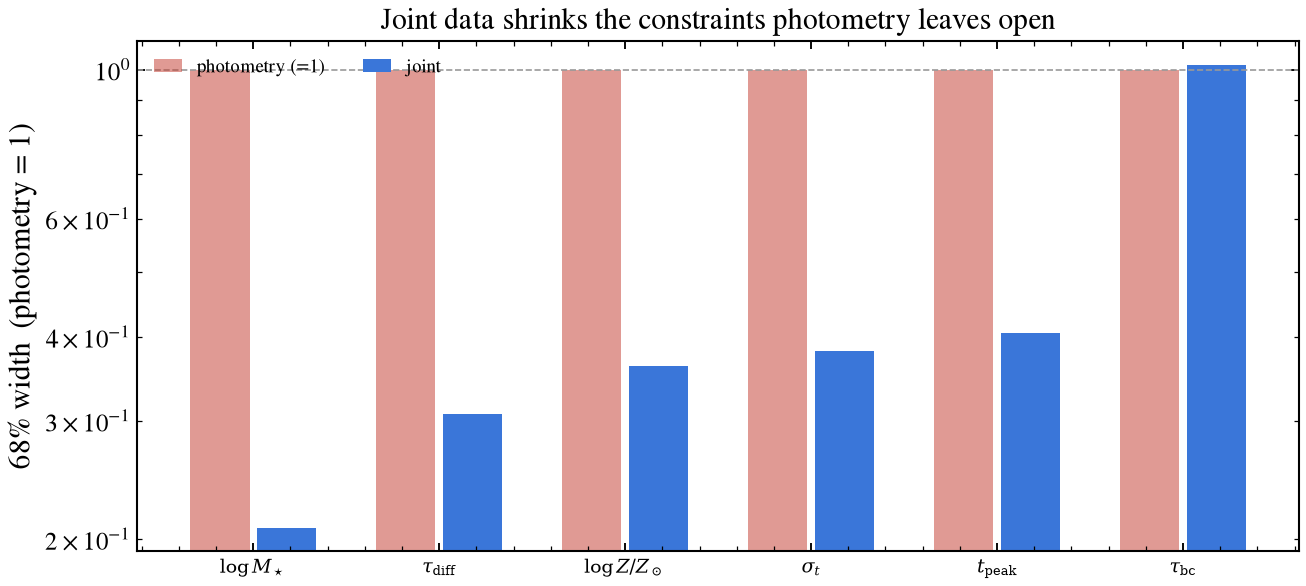

In [6]:
params = model_joint.spec.free_params
labels = {
    "met_logzsol": r"$\log Z/Z_\odot$",
    "dust_tau_bc": r"$\tau_{\rm bc}$",
    "dust_tau_diff": r"$\tau_{\rm diff}$",
    "sfh_tsnorm_log_total_mass": r"$\log M_\star$",
    "sfh_tsnorm_peak_lbt_gyr": r"$t_{\rm peak}$",
    "sfh_tsnorm_width_gyr": r"$\sigma_t$",
    "sfh_tsnorm_skew": "skew",
    "sfh_tsnorm_trunc": "trunc",
}


def width(post, p):
    s = np.asarray(post.samples[p])
    lo, hi = np.percentile(s, [16, 84])
    return hi - lo


w_phot = {p: width(post_phot, p) for p in params}
w_joint = {p: width(post_joint, p) for p in params}

# Compute and report constraint improvements
ratio_phot_over_joint = {p: w_phot[p] / w_joint[p] for p in params}
best_improved = sorted(ratio_phot_over_joint.items(), key=lambda x: -x[1])[:3]
print("\nConstraint improvement (photometry width / joint width):", flush=True)
for p, ratio in best_improved:
    print(f"  {p:30s}: {ratio:5.2f}x tighter with spectrum", flush=True)

order = sorted(params, key=lambda p: w_joint[p] / w_phot[p])
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.axhline(1.0, color="0.6", lw=0.8, ls="--")
ax.bar(
    x - 0.18, [1.0 for _ in order], width=0.32, color=C_DATA, alpha=0.5, label="photometry (=1)"
)
ax.bar(x + 0.18, [w_joint[p] / w_phot[p] for p in order], width=0.32, color=C_POST, label="joint")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([labels.get(p, p) for p in order], fontsize=9)
ax.set_ylabel("68% width  (photometry = 1)")
ax.set_title("Joint data shrinks the constraints photometry leaves open")
ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_constraint_widths.png", dpi=200, bbox_inches="tight")
plt.show()

## Recovery

Truth vs joint-posterior 16/50/84. With converged chains (R̂ < 1.05) the
intervals are trustworthy; the spectrum pulls metallicity and the dust split
back onto the truth that photometry alone could not separate.

In [7]:
print(f"{'parameter':<28}{'truth':>9}{'p16':>9}{'p50':>9}{'p84':>9}  cover", flush=True)
print("-" * 66, flush=True)
n_cov = 0
for p in params:
    s = np.asarray(post_joint.samples[p])
    lo, med, hi = np.percentile(s, [16, 50, 84])
    tv = float(truth_full[p])
    ok = lo <= tv <= hi
    n_cov += ok
    print(
        f"{p:<28}{tv:>9.3f}{lo:>9.3f}{med:>9.3f}{hi:>9.3f}  {'ok' if ok else 'miss'}", flush=True
    )
print(f"\n68% coverage: {n_cov}/{len(params)}", flush=True)

parameter                       truth      p16      p50      p84  cover


------------------------------------------------------------------


dust_tau_bc                     0.300    0.145    0.468    0.845  ok


dust_tau_diff                   0.250    0.225    0.251    0.280  ok


met_logzsol                    -0.300   -0.306   -0.277   -0.244  ok


sfh_tsnorm_log_total_mass      10.500   10.489   10.495   10.500  miss


sfh_tsnorm_peak_lbt_gyr         2.024    1.891    1.969    2.059  ok


sfh_tsnorm_width_gyr            0.483    0.450    0.472    0.496  ok



68% coverage: 5/6


## Posterior SED

Observed photometry (labeled by band) and the optical spectrum on a single
F_ν axis, joint posterior model SED behind them. The shaded band marks the
spectral window, expanded in the inset. A single posterior explains the
broadband points and the spectrum at the same time.

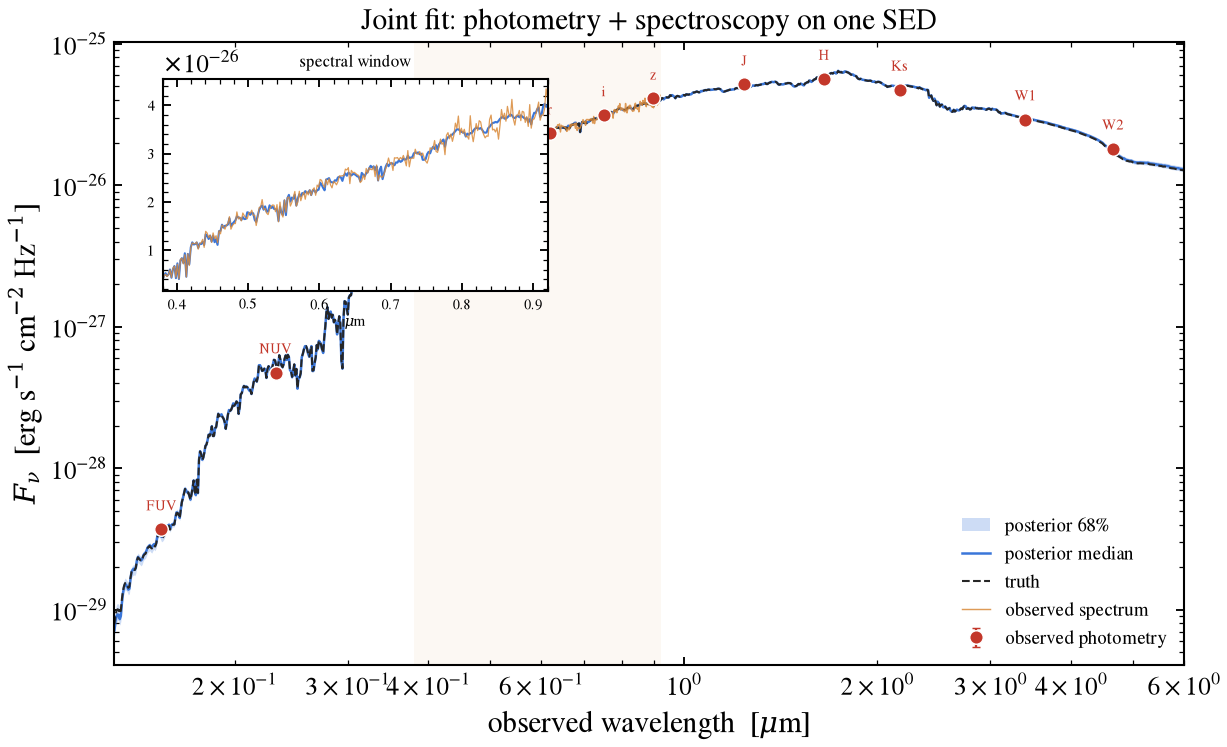

In [8]:
N_DRAW = 60
idx = np.linspace(0, len(next(iter(post_joint.samples.values()))) - 1, N_DRAW).astype(int)
fixed = model_joint.spec.get_fixed_values()
draws = [{**fixed, **{k: float(v[i]) for k, v in post_joint.samples.items()}} for i in idx]

DL = cosmology.luminosity_distance(Z_GAL)
WAVE_FULL = np.geomspace(1300.0, 6.0e4, 1000)
w_full_um = WAVE_FULL / 1e4
w_spec_um = np.asarray(WAVE_OBS) / 1e4


def sed_fnu(p):
    pred = model_joint.predict(p)
    lnu_interp = np.interp(
        WAVE_FULL / (1.0 + Z_GAL), np.asarray(model_joint.wavelengths), np.asarray(pred.rest_sed())
    )
    return np.asarray(lnu_to_fnu(jnp.asarray(lnu_interp), DL, Z_GAL))


sed_draws = np.stack([sed_fnu(p) for p in draws])
sed_lo, sed_med, sed_hi = np.percentile(sed_draws, [16, 50, 84], axis=0)
sed_truth = sed_fnu(truth_full)

BAND_LABELS = ["FUV", "NUV", "u", "g", "r", "i", "z", "J", "H", "Ks", "W1", "W2"]

fig_h, ax = plt.subplots(figsize=(9.2, 5.4))
ax.axvspan(w_spec_um.min(), w_spec_um.max(), color=C_SPEC, alpha=0.06, lw=0, zorder=0)
ax.fill_between(w_full_um, sed_lo, sed_hi, color=C_POST, alpha=0.25, lw=0, label="posterior 68%")
ax.plot(w_full_um, sed_med, color=C_POST, lw=1.2, label="posterior median")
ax.plot(w_full_um, sed_truth, color=C_TRUTH, lw=1.0, ls="--", label="truth")
ax.plot(
    w_spec_um, flux_spec, color=C_SPEC, lw=0.7, alpha=0.85, zorder=4, label="observed spectrum"
)
ax.errorbar(
    wave_eff_um,
    flux_phot,
    yerr=n_phot,
    fmt="o",
    ms=6.5,
    color=C_DATA,
    mec="white",
    mew=0.7,
    elinewidth=1.1,
    capsize=2,
    zorder=6,
    label="observed photometry",
)
for name, x, y, e in zip(BAND_LABELS, wave_eff_um, flux_phot, n_phot):
    ax.annotate(
        name,
        (x, y + e),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        va="bottom",
        fontsize=7,
        color=C_DATA,
        zorder=7,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(w_full_um.min(), w_full_um.max())
ax.set_xlabel(r"observed wavelength  [$\mu$m]")
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.set_title("Joint fit: photometry + spectroscopy on one SED")
ax.legend(frameon=False, fontsize=9, loc="lower right")

# Inset in the empty upper-left corner (above the rising SED) so it does not
# cover the spectrum or the NIR photometry.
spec_draws_arr = np.stack(
    [np.asarray(model_joint.predict_spectrum(p, wave_obs=WAVE_OBS)) for p in draws]
)
sp_lo, sp_med, sp_hi = np.percentile(spec_draws_arr, [16, 50, 84], axis=0)
axin = ax.inset_axes([0.045, 0.60, 0.36, 0.34], zorder=10)
axin.set_facecolor("white")
axin.patch.set_alpha(1.0)
axin.fill_between(w_spec_um, sp_lo, sp_hi, color=C_POST, alpha=0.30, lw=0)
axin.plot(w_spec_um, sp_med, color=C_POST, lw=1.0)
axin.plot(w_spec_um, flux_spec, color=C_SPEC, lw=0.6, alpha=0.85)
axin.set_xlim(w_spec_um.min(), w_spec_um.max())
axin.tick_params(labelsize=7)
axin.set_xlabel(r"$\mu$m", fontsize=7, labelpad=1)
axin.set_title("spectral window", fontsize=8)
fig_h.savefig(FIG_DIR / "07_joint_sed.png", dpi=300, bbox_inches="tight")
plt.show()

## Corner — joint posterior

Free parameters with truth dashed. The metallicity and dust columns are now
tight and centered on the truth — neither dataset managed that on its own.

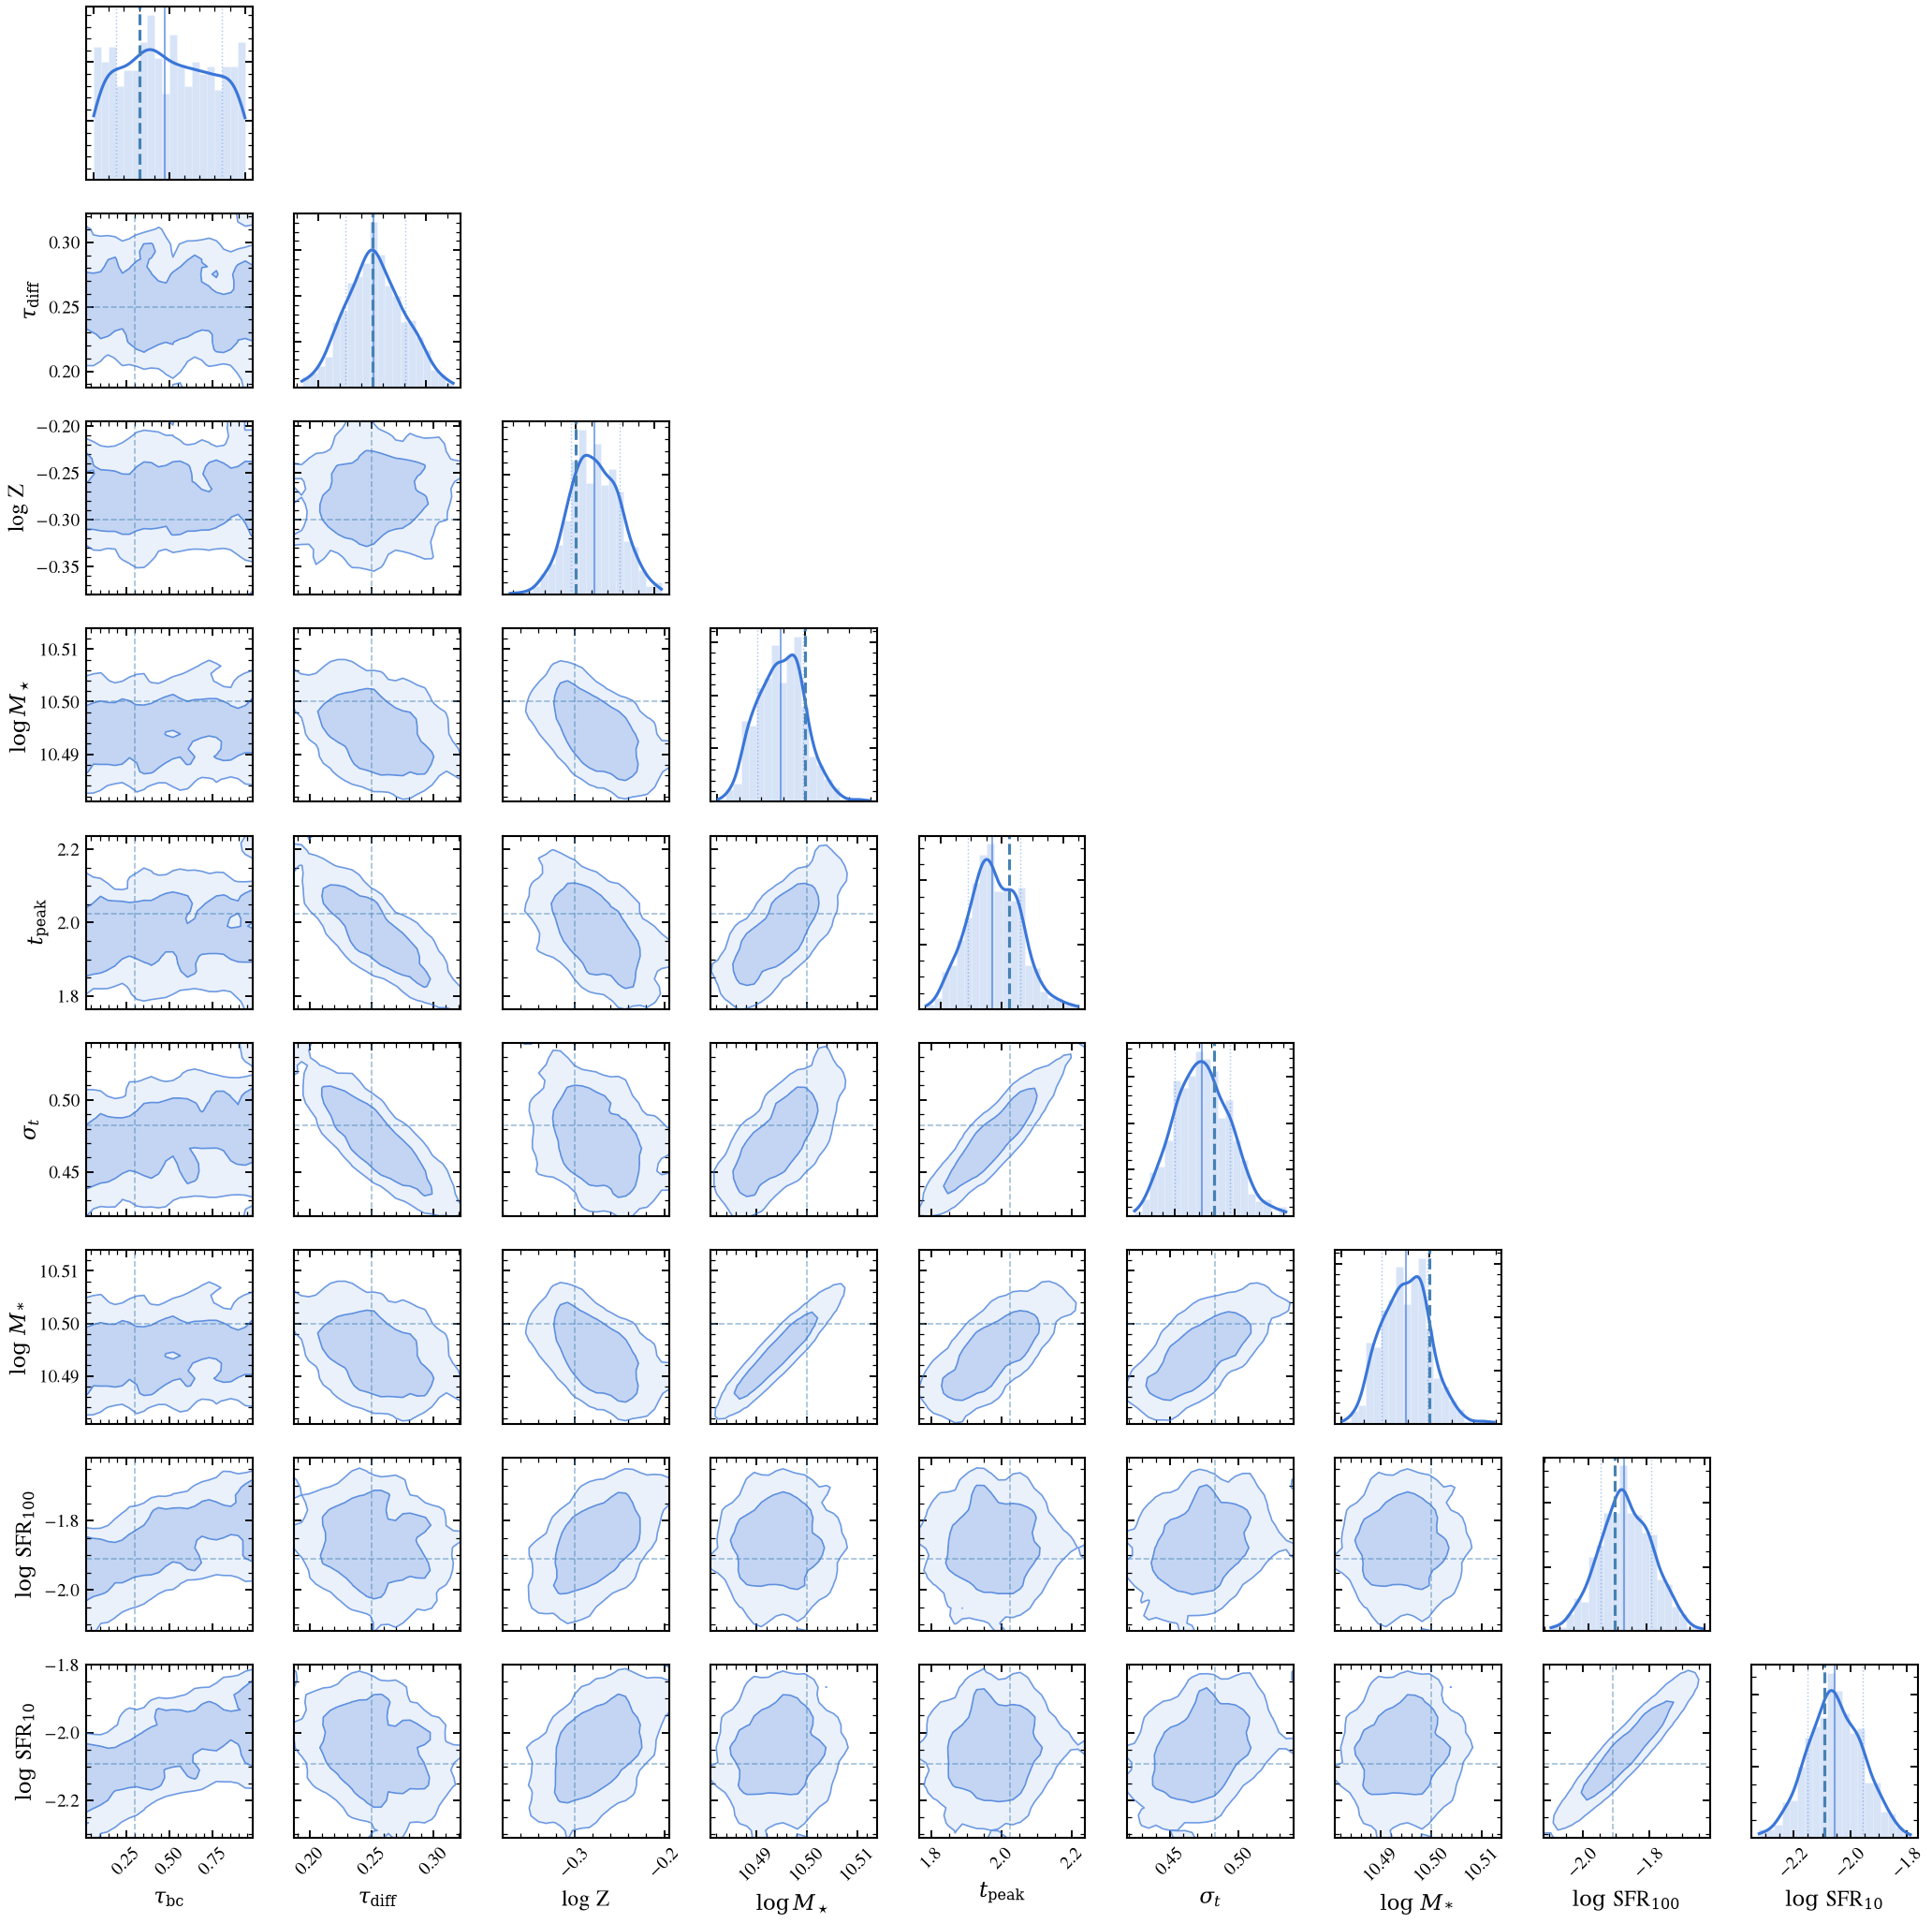

In [9]:
fig_corner = post_joint.plot_corner(truths=truth_full, color=C_POST)
for ax_c in fig_corner.axes:  # readable axis labels in place of parameter keys
    if ax_c.get_xlabel() in labels:
        ax_c.set_xlabel(labels[ax_c.get_xlabel()], fontsize=11)
    if ax_c.get_ylabel() in labels:
        ax_c.set_ylabel(labels[ax_c.get_ylabel()], fontsize=11)
fig_corner.savefig(FIG_DIR / "07_corner.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

Photometry constrains the SED shape and stellar mass; the optical spectrum
adds absorption-line depths that break the metallicity–dust–age degeneracy.
Compare the widths printed below against the photometry-only fit to see how
much the spectrum adds.

In [10]:
from contextlib import suppress

with suppress(Exception):
    tengri.cite(post_joint)

component         name                kind              citation                                
────────────────  ──────────────────  ────────────────  ────────────────────────────────────────
framework         tengri              framework         Cooray et al. (2026, Paper I)           
ssp               DSPS                framework         Hearin et al. 2023 (MNRAS 521, 1741)    
framework         JAX                 framework         Bradbury et al. 2018                    
sfh               tsnorm              sfh_model         Bellstedt et al. 2020 (arXiv:2005.11917)
dust              two_component       dust_model        Charlot & Fall 2000 (ApJ 539, 718)      
dust_attenuation  calzetti            dust_attenuation  Calzetti et al. 2000 (ApJ 533, 682)     
dust_emission     modified_blackbody  dust_emission     Casey 2012 (MNRAS 425, 3094)            
[7 results: mixed]

% ────────────────────────────────────────────────────────────────
%  Citations for 7 components used by th